# Assignment 3: Medical Image Generation with Autoencoders
### 2025-2026


## Objectives
 - Understand and apply autoencoders to medical image data  
 - Perform pre-processing on chest X‑ray images  
 - Build and train a **Convolutional Autoencoder** (AE) and a **Variational Autoencoder** (VAE)  
 - Evaluate reconstruction quality and generate synthetic medical images  
 - Analyse the latent space of the VAE

 ## Data

 We use the **PneumoniaMNIST** dataset (a MedMNIST 2D dataset).  
 It contains 5,856 paediatric chest X‑ray images (28×28 grayscale) labelled as Normal (0) or Pneumonia (1).

 Source: [MedMNIST](https://medmnist.com/) (Yang et al., 2021).  
 The dataset is automatically downloaded when using the `medmnist` library.

 ## Instructions
 - Complete the exercises in the provided code cells.  
 - Add your answers to the questions in a separate **Word/PDF report** following the report template.  


### 0. Setup & Dependencies

In [1]:
!pip install -q medmnist scikit-learn scikit-image


### 1. Load and Explore the Chest X‑ray Data

## Exercise 1

 1. Load the PneumoniaMNIST dataset (train+test).  
 2. Combine them into a single set for unsupervised learning (labels are ignored).  
 3. Visualise 16 sample images.  
 4. Answer the questions in your report.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, ConcatDataset
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np
from medmnist import PneumoniaMNIST, INFO
from tqdm import tqdm

# Define transform: ToTensor converts images to [0, 1] range
transform = transforms.Compose([
    transforms.ToTensor(),
])

# Download train & test splits, combine them into one big unsupervised dataset
train_data = PneumoniaMNIST(split='train', download=True, transform=transform)
test_data  = PneumoniaMNIST(split='test',  download=True, transform=transform)
all_data   = ConcatDataset([train_data, test_data])

# get total number of images
print(f'Total images: {len(all_data)}')
# get original image size
img, label = all_data[0]
print(f'Original image shape: {img.shape}')

Total images: 5332
Original image shape: torch.Size([1, 28, 28])


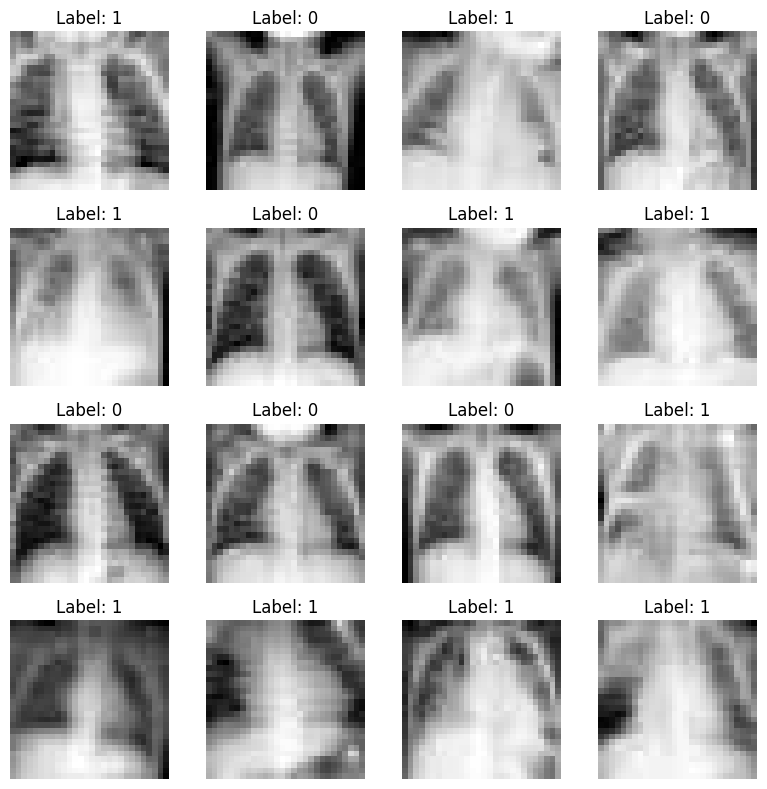

In [3]:
# Visualize 16 sample images
def show_images(dataset, num_images=16):
    loader = DataLoader(dataset, batch_size=num_images, shuffle=True)
    images, labels = next(iter(loader))
    
    plt.figure(figsize=(8, 8))
    for i in range(num_images):
        plt.subplot(4, 4, i + 1)
        plt.imshow(images[i].squeeze(), cmap='gray')
        plt.title(f'Label: {labels[i].item()}')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

show_images(all_data)

### 2. Convolutional Autoencoder (AE)

 Build a CNN‑based autoencoder that compresses a 28×28 image to a latent vector (e.g., dimension 64) and reconstructs it.

## Exercise 2
1. Define the `ConvAutoencoder` class (encoder–decoder).  
2. Train the model with **BCE loss** for 30 epochs (use the whole dataset, no labels).  
3. Plot the training loss curve.  
4. Visualise original vs. reconstructed images from the test split.  
5. Compute the average **SSIM** (Structural Similarity) between original and reconstructed test images (you may use `skimage.measure.compare_ssim`).  
6. Discuss the reconstruction quality.


AE Epoch 1/30:   0%|                                     | 0/84 [00:00<?, ?it/s]


AE Epoch 1/30:   1%|▎                            | 1/84 [00:00<00:28,  2.94it/s]


AE Epoch 1/30:   5%|█▍                           | 4/84 [00:00<00:09,  8.77it/s]


AE Epoch 1/30:   8%|██▍                          | 7/84 [00:00<00:08,  9.32it/s]


AE Epoch 1/30:  14%|████                        | 12/84 [00:00<00:04, 16.90it/s]

...


AE Epoch 30/30:  83%|██████████████████████▌    | 70/84 [00:03<00:00, 24.18it/s]


AE Epoch 30/30:  89%|████████████████████████   | 75/84 [00:03<00:00, 29.46it/s]


AE Epoch 30/30:  94%|█████████████████████████▍ | 79/84 [00:03<00:00, 24.93it/s]


AE Epoch 30/30: 100%|███████████████████████████| 84/84 [00:03<00:00, 30.08it/s]

Epoch [30/30], Loss: 0.6253


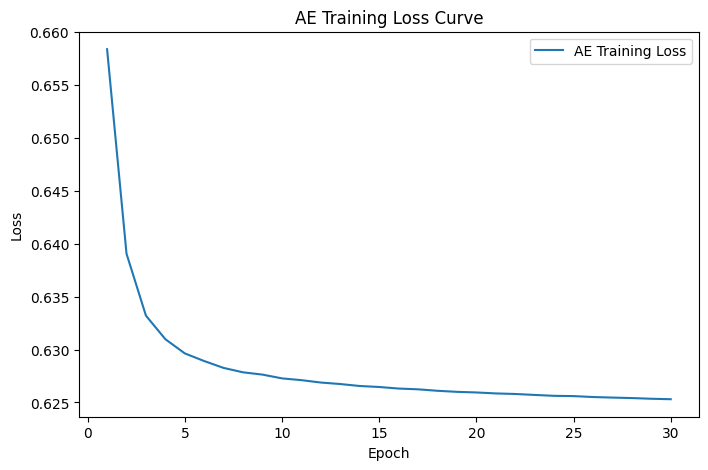

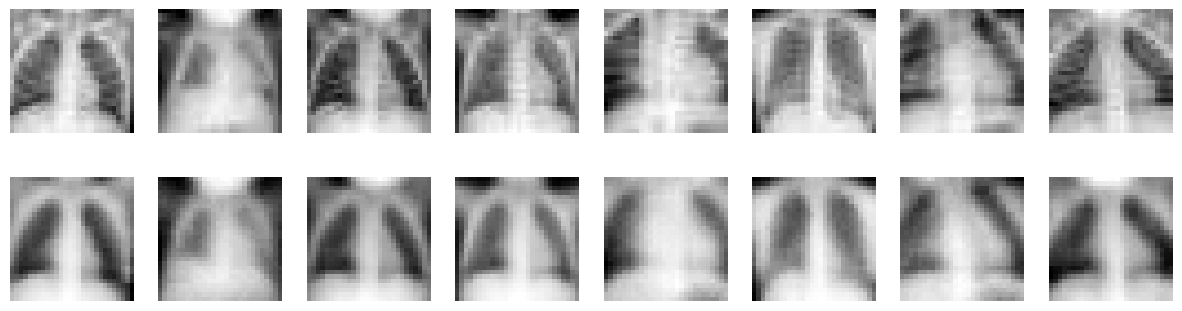

[W512 22:37:42.413080642 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W512 22:37:42.430839778 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W512 22:37:42.458753057 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W512 22:37:42.468162884 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W512 22:37:42.500661694 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W512 22:37:42.519195002 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W512 22:37:43.558625978 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W512 22:37:43.567409704 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W512 22:37:43.580527507 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W512 22:37:43.585447892 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W512 22:3

[W512 22:37:43.636032640 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W512 22:37:43.641974905 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W512 22:37:43.655913447 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W512 22:37:43.661327197 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W512 22:37:43.672673324 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W512 22:37:43.678113038 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W512 22:37:43.680046820 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W512 22:37:43.685609357 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W512 22:37:43.687721126 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W512 22:37:43.691221876 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W512 22:3

[W512 22:37:43.846240934 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W512 22:37:43.873972467 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W512 22:37:43.883205600 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W512 22:37:43.884913902 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W512 22:37:43.890163119 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W512 22:37:43.915995905 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W512 22:37:43.930648208 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W512 22:37:43.954364286 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W512 22:37:43.963184939 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W512 22:37:43.989496004 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W512 22:3

[W512 22:37:43.055078850 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W512 22:37:43.075242153 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W512 22:37:43.085079721 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W512 22:37:43.113702138 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W512 22:37:43.117836575 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W512 22:37:43.125453166 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W512 22:37:43.133197693 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W512 22:37:43.138321882 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W512 22:37:43.142068599 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W512 22:37:43.167091836 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W512 22:3

[W512 22:37:43.260105090 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W512 22:37:43.291380550 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W512 22:37:43.304194592 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W512 22:37:43.342474479 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W512 22:37:43.357172261 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W512 22:37:43.388478668 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W512 22:37:43.403302927 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W512 22:37:43.431399545 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W512 22:37:43.442082418 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.


...

[W512 22:37:45.926690595 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W512 22:37:45.955114866 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W512 22:37:45.961592548 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W512 22:37:45.984583907 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W512 22:37:45.998205872 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W512 22:37:45.048317866 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W512 22:37:45.069172139 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W512 22:37:45.117778744 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W512 22:37:45.127119787 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.


[W512 22:37:45.164617164 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W512 22:37:45.169100214 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W512 22:37:45.200537719 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W512 22:37:45.211155689 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W512 22:37:45.247810197 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W512 22:37:45.256154417 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W512 22:37:45.285486213 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W512 22:37:45.295071592 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W512 22:37:45.328429852 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W512 22:37:45.339476891 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.


[W512 22:37:45.369323531 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W512 22:37:45.378069060 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W512 22:37:45.405806240 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W512 22:37:45.415132990 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W512 22:37:45.438515372 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W512 22:37:45.441602022 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W512 22:37:45.455107510 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W512 22:37:45.462205129 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W512 22:37:45.498105711 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W512 22:37:45.504072089 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W512 22:3

Average SSIM (100 test images): 0.9158


[W512 22:37:46.597633351 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W512 22:37:46.608025665 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.


In [4]:
class ConvAutoencoder(nn.Module):
    def __init__(self, latent_dim=64):
        super(ConvAutoencoder, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, latent_dim)
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32 * 7 * 7),
            nn.Unflatten(1, (32, 7, 7)),
            nn.ConvTranspose2d(32, 16, 2, stride=2),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 2, stride=2),
            nn.Sigmoid()
        )

    def forward(self, x):
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        return reconstructed

# Training Hyperparameters
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
latent_dim = 64
learning_rate = 1e-3
batch_size = 64
epochs = 30

model_ae = ConvAutoencoder(latent_dim).to(device)
optimizer = optim.Adam(model_ae.parameters(), lr=learning_rate)
criterion = nn.BCELoss()

train_loader = DataLoader(all_data, batch_size=batch_size, shuffle=True)

# Training Loop
loss_history_ae = []
for epoch in range(epochs):
    model_ae.train()
    running_loss = 0.0
    for images, _ in tqdm(train_loader, desc=f'AE Epoch {epoch+1}/{epochs}', leave=False):
        images = images.to(device)
        
        optimizer.zero_grad()
        outputs = model_ae(images)
        loss = criterion(outputs, images)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
    
    epoch_loss = running_loss / len(all_data)
    loss_history_ae.append(epoch_loss)
    print(f'Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.4f}')

# Plot training loss
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), loss_history_ae, label='AE Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('AE Training Loss Curve')
plt.legend()
plt.show()

from skimage.metrics import structural_similarity as ssim

def evaluate_ae(model, dataset, num_samples=8):
    model.eval()
    loader = DataLoader(dataset, batch_size=num_samples, shuffle=True)
    images, _ = next(iter(loader))
    images = images.to(device)
    
    with torch.no_grad():
        reconstructed = model(images)
    
    images = images.cpu().numpy()
    reconstructed = reconstructed.cpu().numpy()
    
    plt.figure(figsize=(15, 4))
    for i in range(num_samples):
        # Original
        plt.subplot(2, num_samples, i + 1)
        plt.imshow(images[i].squeeze(), cmap='gray')
        plt.axis('off')
        if i == 0: plt.ylabel('Original')
        
        # Reconstructed
        plt.subplot(2, num_samples, i + 1 + num_samples)
        plt.imshow(reconstructed[i].squeeze(), cmap='gray')
        plt.axis('off')
        if i == 0: plt.ylabel('Reconstructed')
    plt.show()

    # Calculate average SSIM on a larger subset
    ssim_scores = []
    test_loader = DataLoader(test_data, batch_size=1, shuffle=False)
    for i, (img, _) in enumerate(test_loader):
        if i >= 100: break # Use 100 images for speed
        img = img.to(device)
        with torch.no_grad():
            rec = model(img)
        img_np = img.cpu().squeeze().numpy()
        rec_np = rec.cpu().squeeze().numpy()
        score = ssim(img_np, rec_np, data_range=1.0)
        ssim_scores.append(score)
    
    print(f'Average SSIM (100 test images): {np.mean(ssim_scores):.4f}')

evaluate_ae(model_ae, test_data)

### 3. Variational Autoencoder (VAE)

Transform the AE into a **generative** VAE that can create novel chest X‑rays.

## Exercise 3

  1. Implement the `VAE` class (encoder outputs `mu` and `logvar`; reparameterisation trick).  
  2. Train for 50 epochs using a loss that combines BCE reconstruction and KL divergence.  
  3. Plot the training loss and the separate reconstruction and KL terms (if you wish).  
  4. Compare the reconstruction sharpness with the AE.

  5. Generate 16 synthetic chest X‑rays by sampling from the standard normal prior.  
  6. Perform **latent space interpolation** between two random vectors and visualise the morphing.  
  7. Use **t‑SNE** to visualise the latent `mu` vectors of 1,000 test images, coloured by the (withheld) Normal/Pneumonia label.  
  8. Interpret the t‑SNE plot.


VAE Epoch 1/50:   0%|                                    | 0/84 [00:00<?, ?it/s]


VAE Epoch 1/50:   1%|▎                           | 1/84 [00:00<00:18,  4.53it/s]


VAE Epoch 1/50:   2%|▋                           | 2/84 [00:00<00:18,  4.38it/s]


VAE Epoch 1/50:   4%|█                           | 3/84 [00:01<00:31,  2.54it/s]


VAE Epoch 1/50:   5%|█▎                          | 4/84 [00:01<00:37,  2.13it/s]

...


VAE Epoch 50/50:  81%|█████████████████████     | 68/84 [00:01<00:00, 36.57it/s]


VAE Epoch 50/50:  87%|██████████████████████▌   | 73/84 [00:01<00:00, 38.82it/s]


VAE Epoch 50/50:  93%|████████████████████████▏ | 78/84 [00:02<00:00, 38.95it/s]


VAE Epoch 50/50:  99%|█████████████████████████▋| 83/84 [00:02<00:00, 40.57it/s]

Epoch [50/50], Loss: 571.3166


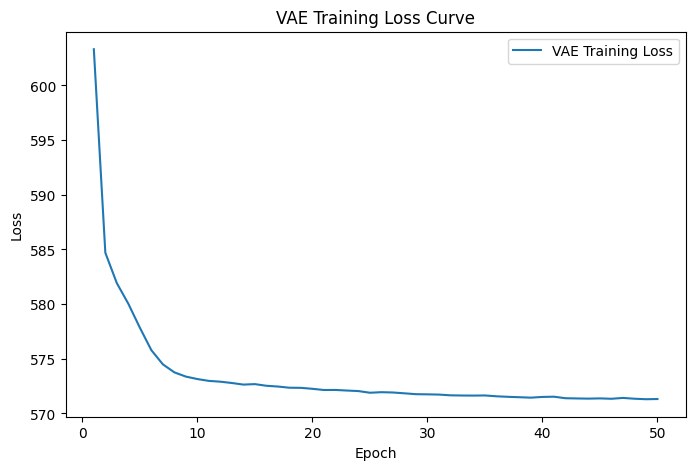

In [5]:
class VAE(nn.Module):
    def __init__(self, latent_dim=64):
        super(VAE, self).__init__()
        # Encoder
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Flatten()
        )
        self.fc_mu = nn.Linear(32 * 7 * 7, latent_dim)
        self.fc_logvar = nn.Linear(32 * 7 * 7, latent_dim)
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32 * 7 * 7),
            nn.Unflatten(1, (32, 7, 7)),
            nn.ConvTranspose2d(32, 16, 2, stride=2),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 2, stride=2),
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder_conv(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

def vae_loss_function(recon_x, x, mu, logvar):
    BCE = nn.functional.binary_cross_entropy(recon_x, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD

# Training Hyperparameters
model_vae = VAE(latent_dim).to(device)
optimizer_vae = optim.Adam(model_vae.parameters(), lr=learning_rate)
vae_epochs = 50

# Training Loop
loss_history_vae = []
for epoch in range(vae_epochs):
    model_vae.train()
    running_loss = 0.0
    for images, _ in tqdm(train_loader, desc=f'VAE Epoch {epoch+1}/{vae_epochs}', leave=False):
        images = images.to(device)
        
        optimizer_vae.zero_grad()
        recon_batch, mu, logvar = model_vae(images)
        loss = vae_loss_function(recon_batch, images, mu, logvar)
        loss.backward()
        optimizer_vae.step()
        
        running_loss += loss.item()
    
    epoch_loss = running_loss / len(all_data.datasets[0]) # Approximation for train set size
    loss_history_vae.append(epoch_loss)
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{vae_epochs}], Loss: {epoch_loss:.4f}')

# Plot training loss
plt.figure(figsize=(8, 5))
plt.plot(range(1, vae_epochs + 1), loss_history_vae, label='VAE Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('VAE Training Loss Curve')
plt.legend()
plt.show()